#### Find the optimal depth (number of hidden layers) and width(number of neurons in each hidden layer) for the neural network designed in Question 1 and 2.

##### Plot the mean cross-validation accuracies on the final epoch for at least 8 different combinations of different depth (limit to 1-3 layers) and widths (limit to 64, 128 or 256 neurons) using a scatter plot. You may consider different number of neurons for each hidden layer within an architecture. Continue using 5-fold cross validation on the training dataset. 

##### Identify the architecture with the highest validation accuracy among all tested combinations. 

##### Explain the possible reasons why it performed better than the other architectures. 

##### In general, discuss whether accuracy alone is sufficient when selecting the best model. Plot the train and test accuracies against training epochs for the most optimal architecture using a line plot.

##### [optional + 2 marks] Implement an alternative approach that searches through these combinations that could significantly reduce the computational time but achieve similar search results, without enumeration all the possibilities.




This might take a while to run, so plan your time carefully.

1.Firstly, we import relevant libraries.

In [4]:
import tqdm
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from scipy.io import wavfile as wav

from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from common_utils import set_seed

2.To reduce repeated code, place your

- network (MLP defined in QA1)
- torch datasets (CustomDataset defined in QA1)
- loss function (loss_fn defined in QA1)

in a separate file called **common_utils.py**

Import them into this file. You will not be repenalised for any error in QA1 here as the code in QA1 will not be remarked.

The following code cell will not be marked.

In [6]:
# YOUR CODE HERE
from common_utils import EarlyStopper, loss_fn, MLP, CustomDataset, split_dataset, preprocess_dataset, train_loop, test_loop

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

no_features = 77
no_labels = 1
dropout_rate = 0.3

batch_size = 64
weight_decay = 0.0005
max_epochs = 200
patience = 5

no_folds = 5

seed = 42

# setting seed
set_seed(seed)

3.Perform hyperparameter tuning for different number of  hidden layers and neurons with 5-fold cross validation.

In [8]:
def train(model, X_train_scaled, y_train2, X_val_scaled, y_val2, learning_rate):
    # YOUR CODE HERE
    train_dataset = CustomDataset(X_train_scaled, y_train2)
    val_dataset = CustomDataset(X_val_scaled, y_val2)

    train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
    val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)

    optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate, weight_decay = weight_decay)
    early_stopper = EarlyStopper(patience = patience, min_delta = 0)

    train_accuracies = []
    train_losses = []
    test_accuracies = []
    test_losses = []
    times = []

    for epoch in range(max_epochs):
        train_loss, train_acc = train_loop(train_loader, model, loss_fn, optimizer)
        val_loss, val_acc = test_loop(val_loader, model, loss_fn)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        test_losses.append(val_loss)
        test_accuracies.append(val_acc)

        times.append(epoch + 1)

        if early_stopper.early_stop(val_loss):
            break

    return train_accuracies, train_losses, test_accuracies, test_losses, times

In [9]:
def find_optimal_hyperparameter(X_train, y_train, parameters, mode, learning_rate):
    # YOUR CODE HERE
    cross_validation_accuracies = []
    cross_validation_times = []

    kf = KFold(n_splits = no_folds, shuffle = True, random_state = seed)

    for no_hidden in parameters:
        print(f"Current {mode}: {len(no_hidden)} hidden layers - {no_hidden} neurons correspondingly")
        
        fold_accuracies = []
        fold_epochs = []
        fold_number = 1

        for train_idx, val_idx in kf.split(X_train):
            X_tr = X_train[train_idx]
            X_val = X_train[val_idx]
            y_tr = y_train[train_idx]
            y_val = y_train[val_idx]

            X_tr_scaled, X_val_scaled = preprocess_dataset(X_tr, X_val)

            model = MLP(no_features, no_hidden, no_labels, dropout_rate).to(device)

            train_acc, train_loss, val_acc, val_loss, times = train(model, X_tr_scaled, y_tr, X_val_scaled, y_val, learning_rate)

            fold_accuracies.append(val_acc[-1])
            fold_epochs.append(times[-1])

            print(f"Fold {fold_number}: Accuracy = {val_acc[-1]:.4f}, Epochs = {times[-1]}")
            fold_number += 1

        cross_validation_accuracies.append(np.mean(fold_accuracies))
        cross_validation_times.append(np.mean(fold_epochs))

        print(f"Mean Accuracy: {cross_validation_accuracies[-1]:.4f}, Mean Epochs: {cross_validation_times[-1]:.2f}\n")

    return cross_validation_accuracies, cross_validation_times

In [10]:
'''
optimal_lr = 0. Fill your optimal learning rate in the following code.
'''

# YOUR CODE HERE
optimal_lr = 0.001

no_neurons = [64, 128, 256]
one_layer_parameters = [[n1] for n1 in no_neurons]
two_layer_parameters = [[n1, n2] for n1 in no_neurons for n2 in no_neurons]
three_layer_parameters = [[n1, n2, n3] for n1 in no_neurons for n2 in no_neurons for n3 in no_neurons]
parameters = one_layer_parameters + two_layer_parameters + three_layer_parameters

df = pd.read_csv('simplified.csv')
df['label'] = df['filename'].str.split('_').str[-2]

X_train, y_train, X_test, y_test = split_dataset(
    df,
    columns_to_drop = ['filename','label'],
    test_size = 0.25,
    random_state = seed
)

cross_validation_accuracies, cross_validation_times = find_optimal_hyperparameter(X_train.to_numpy(), y_train, parameters, 'Architecture', optimal_lr)

Current Architecture: 1 hidden layers - [64] neurons correspondingly
Fold 1: Accuracy = 0.6611, Epochs = 42
Fold 2: Accuracy = 0.6551, Epochs = 38
Fold 3: Accuracy = 0.6510, Epochs = 32
Fold 4: Accuracy = 0.6648, Epochs = 36
Fold 5: Accuracy = 0.6504, Epochs = 30
Mean Accuracy: 0.6565, Mean Epochs: 35.60

Current Architecture: 1 hidden layers - [128] neurons correspondingly
Fold 1: Accuracy = 0.6567, Epochs = 22
Fold 2: Accuracy = 0.6606, Epochs = 38
Fold 3: Accuracy = 0.6582, Epochs = 28
Fold 4: Accuracy = 0.6858, Epochs = 31
Fold 5: Accuracy = 0.6621, Epochs = 24
Mean Accuracy: 0.6647, Mean Epochs: 28.60

Current Architecture: 1 hidden layers - [256] neurons correspondingly
Fold 1: Accuracy = 0.6722, Epochs = 32
Fold 2: Accuracy = 0.6611, Epochs = 22
Fold 3: Accuracy = 0.6881, Epochs = 35
Fold 4: Accuracy = 0.6952, Epochs = 23
Fold 5: Accuracy = 0.6847, Epochs = 33
Mean Accuracy: 0.6803, Mean Epochs: 29.00

Current Architecture: 2 hidden layers - [64, 64] neurons correspondingly
Fold

4. Plot the mean cross-validation accuracies on the final epoch for at least 8 different combinations of different depth (limit to 1-3 layers) and widths (limit to 64, 128 or 256 neurons) using a scatter plot. 

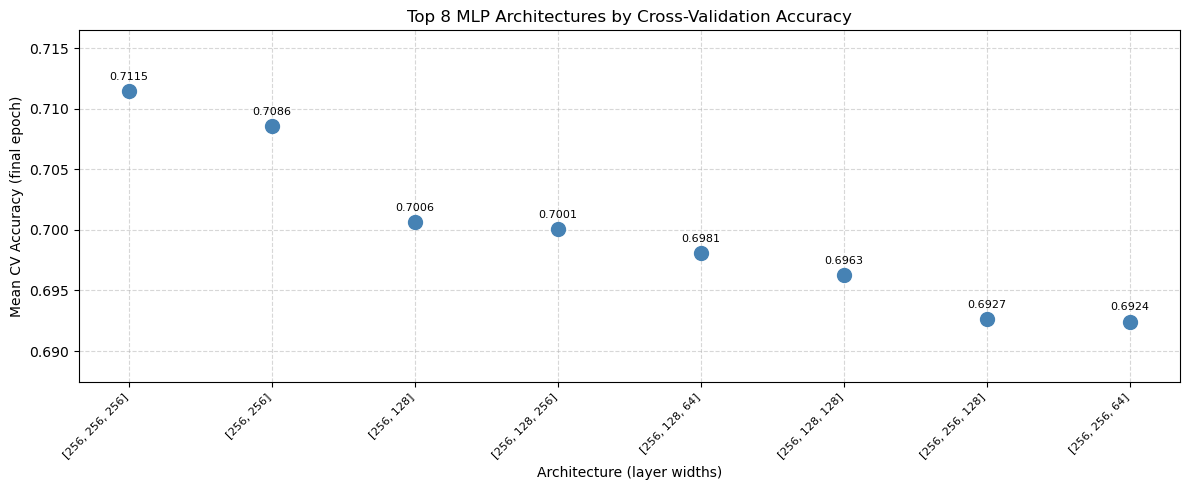

In [24]:
# YOUR CODE HERE
top_8_indices = np.argsort(cross_validation_accuracies)[-8:][::-1]
selected_params = [parameters[i] for i in top_8_indices]
selected_accs = [cross_validation_accuracies[i] for i in top_8_indices]
labels = [str(p) for p in selected_params]

# Dynamic y-axis based on actual data range
y_min = min(selected_accs) - 0.005
y_max = max(selected_accs) + 0.005

plt.figure(figsize=(12, 5))
plt.scatter(range(len(selected_accs)), selected_accs, s = 100, color = 'steelblue', zorder = 3)

for i, (label, acc) in enumerate(zip(labels, selected_accs)):
    plt.annotate(f"{acc:.4f}", (i, acc), textcoords = "offset points", xytext = (0, 8), ha = 'center', fontsize = 8)

plt.xticks(range(len(selected_accs)), labels, rotation = 45, ha = 'right', fontsize = 8)
plt.xlabel('Architecture (layer widths)')
plt.ylabel('Mean CV Accuracy (final epoch)')
plt.title('Top 8 MLP Architectures by Cross-Validation Accuracy')
plt.ylim(y_min, y_max)
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.tight_layout()
plt.show()

5. Select the optimal combination for the depth and width. State the rationale for your selection.

In [26]:
optimal_combination = [256, 256, 256]
reason = """
The [256, 256, 256] architecture achieved the highest validation accuracy of 0.7115 likely because wider layers provide greater capacity to learn 
more complex patterns, while deeper depth (3 hidden layers) enable hierarchical feature extraction. The combination of sufficient & suitable depth 
and width allows the model to capture more complex relationships in the data compared to shallower or narrower architectures.
"""

# YOUR CODE HERE
print(f"The Optimal Architecture: {optimal_combination}")
print(f"The Reason: {reason}")

The Optimal Architecture: [256, 256, 256]
The Reason: 
The [256, 256, 256] architecture achieved the highest validation accuracy of 0.7115 likely because wider layers provide greater capacity to learn 
more complex patterns, while deeper depth (3 hidden layers) enable hierarchical feature extraction. The combination of sufficient & suitable depth 
and width allows the model to capture more complex relationships in the data compared to shallower or narrower architectures.



6.Plot the train and test accuracies against training epochs for the most optimal architecture using a line plot.


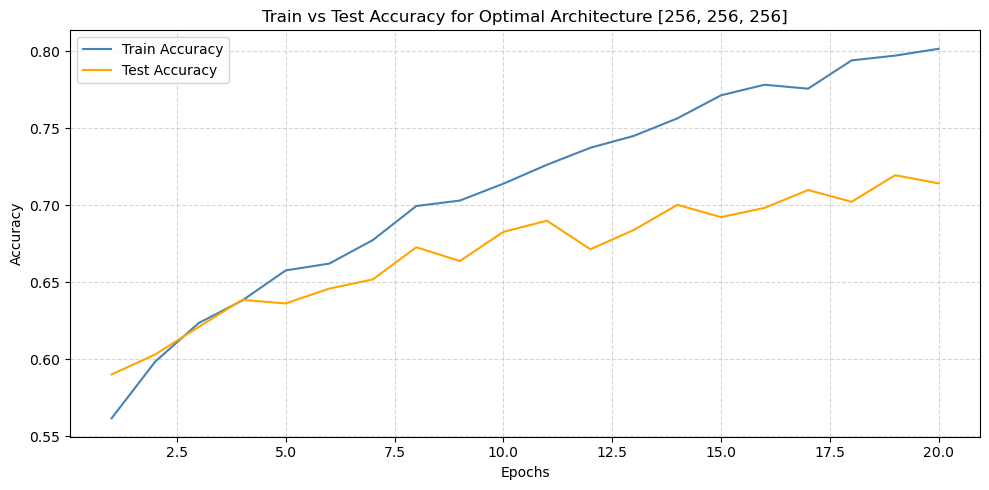

In [61]:
# YOUR CODE HERE
X_train_scaled, X_test_scaled = preprocess_dataset(X_train, X_test)
model = MLP(no_features, optimal_combination, no_labels, dropout_rate).to(device)
train_acc, train_loss, val_acc, val_loss, epochs = train(model, X_train_scaled, y_train, X_test_scaled, y_test, optimal_lr)

plt.figure(figsize = (10, 5))
plt.plot(epochs, train_acc, label = 'Train Accuracy', color = 'steelblue')
plt.plot(epochs, val_acc, label = 'Test Accuracy', color = 'orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title(f'Train vs Test Accuracy for Optimal Architecture {optimal_combination}')
plt.legend()
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.tight_layout()
plt.show()

7.As you've astutely observed, we're facing a significant challenge in enumerating all possible combinations of widths and depths and searching over them. Given the circumstances, could you explore and implement a more efficient method for searching through these combinations that could significantly reduce the computational time but achieve similar search results?

In [91]:
# YOUR CODE HERE
def train_with_epochs(model, X_train_scaled, y_train, X_val_scaled, y_val, learning_rate, max_epochs):
    train_dataset = CustomDataset(X_train_scaled, y_train)
    val_dataset = CustomDataset(X_val_scaled, y_val)

    train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
    val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)

    optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate, weight_decay = weight_decay)
    early_stopper = EarlyStopper(patience = patience, min_delta = 0)

    train_accuracies = []
    train_losses = []
    test_accuracies = []
    test_losses = []
    times = []

    for epoch in range(max_epochs):
        train_loss, train_acc = train_loop(train_loader, model, loss_fn, optimizer)
        val_loss, val_acc = test_loop(val_loader, model, loss_fn)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        test_losses.append(val_loss)
        test_accuracies.append(val_acc)

        times.append(epoch + 1)

        if early_stopper.early_stop(val_loss):
            break

    return train_accuracies, train_losses, test_accuracies, test_losses, times

In [93]:
def successive_halving_search(parameters, X_train, y_train, learning_rate):
    print("Initial architectures:", len(parameters))

    epoch_schedule = [5, 10, 15]
    fold_schedule = [2, 3, 5]
    
    for round_idx, epochs in enumerate(epoch_schedule):
        print(f"\n===== Round {round_idx + 1} | Epochs = {epochs} =====")

        kf = KFold(n_splits = fold_schedule[round_idx], shuffle = True, random_state = seed)
        scores = []

        for arch in parameters:
            fold_scores = []

            for train_idx, val_idx in kf.split(X_train):
                X_tr = X_train[train_idx]
                X_val = X_train[val_idx]
                y_tr = y_train[train_idx]
                y_val = y_train[val_idx]

                X_tr_scaled, X_val_scaled = preprocess_dataset(X_tr, X_val)

                model = MLP(no_features, arch, no_labels, dropout_rate).to(device)
                train_acc, train_loss, val_acc, val_loss, times = train_with_epochs(model, X_tr_scaled, y_tr, X_val_scaled, y_val, learning_rate, epochs)

                fold_scores.append(val_acc[-1])

            mean_score = np.mean(fold_scores)
            scores.append((arch, mean_score))
            print(f"Architecture {arch} → Accuracy {mean_score:.4f}")

        scores.sort(key = lambda x: x[1], reverse = True)
        keep = len(scores) // 2
        parameters = [s[0] for s in scores[:keep]]

        print(f"\nKeeping top {keep} architectures")

        for s in scores[:keep]:
            print("Survivor:", s)

    best3_architecture = parameters[:3]
    print("\nBest 3 Architecture Found:", best3_architecture)

    return best3_architecture

In [95]:
top_3_architecture = successive_halving_search(parameters, X_train.to_numpy(), y_train, optimal_lr)

Initial architectures: 39

===== Round 1 | Epochs = 5 =====
Architecture [64] → Accuracy 0.5815
Architecture [128] → Accuracy 0.5958
Architecture [256] → Accuracy 0.6021
Architecture [64, 64] → Accuracy 0.5864
Architecture [64, 128] → Accuracy 0.5888
Architecture [64, 256] → Accuracy 0.5829
Architecture [128, 64] → Accuracy 0.5970
Architecture [128, 128] → Accuracy 0.5923
Architecture [128, 256] → Accuracy 0.6012
Architecture [256, 64] → Accuracy 0.6002
Architecture [256, 128] → Accuracy 0.6009
Architecture [256, 256] → Accuracy 0.6061
Architecture [64, 64, 64] → Accuracy 0.5849
Architecture [64, 64, 128] → Accuracy 0.5765
Architecture [64, 64, 256] → Accuracy 0.5786
Architecture [64, 128, 64] → Accuracy 0.5820
Architecture [64, 128, 128] → Accuracy 0.5820
Architecture [64, 128, 256] → Accuracy 0.5864
Architecture [64, 256, 64] → Accuracy 0.5791
Architecture [64, 256, 128] → Accuracy 0.5909
Architecture [64, 256, 256] → Accuracy 0.5846
Architecture [128, 64, 64] → Accuracy 0.5923
Archi

In [101]:
name_of_method = "Successive Halving (with Early Stopping)"

results_of_method = """From the best 3 architecture found using this method, they can all be seen present from the Top 8 MLP Architectures Graph using the old brute force
method. So we essentially achieved similar results but significantly reduced computational time. In our case, even though the best architecture found
from the old method has been eliminated early on, we still managed to find the 2nd Best, 4th Best and 7th Best as the top 3 through this method.
"""

reason_of_use = """Successive halving is used to significantly reduce computational time by early-stopping poor-performing architectures. Instead of 
exhausting resources on every possible combination, it allocates more training epochs only to the most promising candidates, allowing 
for a much wider search space to be explored within the same time budget In our case, we also further shorten the time by doing less folds
for less promising candidates.
"""

drawback = """The primary drawback is the risk of "aggressive pruning," where a potentially optimal architecture is eliminated just because it starts learning 
slowly in the first few epochs. Some complex models require more time to converge and might be outshined by simpler, faster-starting models during the 
initial stages, leading to a sub-optimal final selection. In our case, the actual best architecture did get eliminated early on due to this reason.
"""

print(f"Method Used: {name_of_method}\n")
print(f"Top 3 Results Achieved (Sorted Descendingly by Scores): {top_3_architecture}\n")
print(f"Results Explanation: \n{results_of_method}")
print(f"Reason of Method: \n{reason_of_use}")
print(f"Drawback of Method: \n{drawback}")

Method Used: Successive Halving (with Early Stopping)

Top 3 Results Achieved (Sorted Descendingly by Scores): [[256, 256], [256, 128, 256], [256, 256, 128]]

Results Explanation: 
From the best 3 architecture found using this method, they can all be seen present from the Top 8 MLP Architectures Graph using the old brute force
method. So we essentially achieved similar results but significantly reduced computational time. In our case, even though the best architecture found
from the old method has been eliminated early on, we still managed to find the 2nd Best, 4th Best and 7th Best as the top 3 through this method.

Reason of Method: 
Successive halving is used to significantly reduce computational time by early-stopping poor-performing architectures. Instead of 
exhausting resources on every possible combination, it allocates more training epochs only to the most promising candidates, allowing 
for a much wider search space to be explored within the same time budget In our case, we a